# Spot Detection Comparison: Standard vs Bayer-Specific

This notebook compares two spot detection approaches:

1. **Standard Approach**: Demosaic → Detect on grayscale image
2. **Bayer Approach**: Detect on raw R/G/B channels → Merge duplicates

The Bayer approach preserves noise independence by avoiding demosaicing interpolation.

**Key Insight**: The same fluorophore can be detected in multiple color channels. The Bayer approach **automatically merges** nearby detections across channels to avoid duplicate counting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time

# Add src to path
module_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, module_dir)

import IOFunctions
import MaskFunctions
import sCMOSFunctions
from SpotDetectionFunctions import SpotDetection_Functions
from BayerSpotDetection import detect_spots_bayer_multichannel
from PlottingBase import PublicationPlotter

## Configuration

In [2]:
# Test data parameters
data_path = '/media/jbeckwith/Ezra Seagat/test_script/20mW638_10p561_NF_SP_1_MMStack_2-Pos000_000.ome.tif'
frame_index = 5  # Which frame to analyze

# Bayer pattern
pattern = 'RGGB'  # Assumed - verify with camera specs
mosaic_unit = np.array([['R', 'G'], ['G', 'B']])

# Detection parameters
pfa = 1e-4  # Probability of false alarm
sigma = 1.5  # PSF width in pixels
fraction_true = 0.2  # Expected fraction of true spots
merge_distance = 2.0  # Distance threshold for merging duplicates (pixels)

# Plotting
marker_size = 8
zoom_size = 50  # pixels

print(f"Configuration:")
print(f"  Data: {os.path.basename(data_path)}")
print(f"  Frame: {frame_index}")
print(f"  Pattern: {pattern}")
print(f"  PFA: {pfa}")
print(f"  Sigma: {sigma}")
print(f"  Merge distance: {merge_distance} px")

Configuration:
  Data: 20mW638_10p561_NF_SP_1_MMStack_2-Pos000_000.ome.tif
  Frame: 5
  Pattern: RGGB
  PFA: 0.0001
  Sigma: 1.5
  Merge distance: 2.0 px


## Load Data

In [3]:
# Load single frame
io = IOFunctions.IO_Functions()
raw_data = io.read_tiff(data_path, dtype='float32', frame=frame_index)

height, width = raw_data.shape
print(f"Image shape: {height} × {width}")
print(f"Data range: [{raw_data.min():.0f}, {raw_data.max():.0f}] ADU")

# Create default calibration maps
gain_map = np.ones((height, width), dtype=np.float32)
offset_map = np.zeros((height, width), dtype=np.float32)
read_noise = np.ones((height, width), dtype=np.float32) * 1.6
variance = read_noise ** 2

Image shape: 596 × 616
Data range: [22, 373] ADU


## Method 1: Standard Detection (Demosaic → Detect)

In [4]:
print("="*60)
print("METHOD 1: STANDARD DETECTION (Demosaic → Detect)")
print("="*60)

# Demosaic
scmos = sCMOSFunctions.sCMOS_Functions()
demosaiced_image = scmos.variance_aware_malvar_demosaic(
    raw_data, variance_map=variance, offset_map=offset_map,
    gain=gain_map, grayscale=True
)

# Detect spots
spot_detector = SpotDetection_Functions()
t_start = time.time()
detected_puncta_standard = spot_detector.detect_puncta_in_image(
    demosaiced_image, pfa=pfa, sigma=sigma,
    variance=variance, fraction_true=fraction_true
)
t_standard = time.time() - t_start

n_standard = len(detected_puncta_standard) if detected_puncta_standard is not None else 0
print(f"\nDetected {n_standard} spots in {t_standard*1000:.1f}ms")
print(f"Format: [row, col] = [y, x]")

METHOD 1: STANDARD DETECTION (Demosaic → Detect)

Detected 189 spots in 342.0ms
Format: [row, col] = [y, x]


## Method 2: Bayer Detection (Raw Channels → Merge)

In [5]:
print("="*60)
print("METHOD 2: BAYER DETECTION (Raw Channels → Merge)")
print("="*60)

t_start = time.time()
detected_puncta_bayer, metadata = detect_spots_bayer_multichannel(
    raw_data, spot_detector, pattern=pattern,
    pfa=pfa, sigma=sigma, variance=variance,
    channels=['red', 'green', 'blue'],
    merge_distance=merge_distance,
    fraction_true=fraction_true
)
t_bayer = time.time() - t_start

n_bayer = len(detected_puncta_bayer) if detected_puncta_bayer is not None else 0
print(f"\nFinal merged detections: {n_bayer} spots in {t_bayer*1000:.1f}ms")
print(f"Format: [y, x, frame]")

METHOD 2: BAYER DETECTION (Raw Channels → Merge)
Detecting spots in red channel (shape: (1, 298, 308))...
  Found 35 spots in red channel                                                 ?, ?it/s]
Detecting spots in green channel (shape: (1, 596, 308))...
  Found 148 spots in green channel                                              ?, ?it/s]
Detecting spots in blue channel (shape: (1, 298, 308))...
  Found 95 spots in blue channel                                                ?, ?it/s]

Merging nearby detections across channels (distance < 2.0 px)...
  Before merge: 278 total detections
  After merge: 172 total detections
  Removed 106 duplicates (38.1%)

Final merged detections: 172 spots in 656.1ms
Format: [y, x, frame]


## Comparison Statistics

In [6]:
print("="*60)
print("COMPARISON")
print("="*60)

print(f"\nDetection counts:")
print(f"  Standard (demosaic): {n_standard} spots")
print(f"  Bayer (raw→merge):   {n_bayer} spots")
print(f"  Difference:          {n_bayer - n_standard} ({(n_bayer-n_standard)/max(n_standard,1)*100:+.1f}%)")

print(f"\nTiming:")
print(f"  Standard: {t_standard*1000:.1f}ms")
print(f"  Bayer:    {t_bayer*1000:.1f}ms")
print(f"  Speedup:  {t_standard/max(t_bayer,0.001):.2f}×")

if 'n_detections' in metadata:
    print(f"\nBayer per-channel breakdown (before merge):")
    for channel, count in metadata['n_detections'].items():
        print(f"  {channel.capitalize()}: {count} spots")
    print(f"  Total before merge: {sum(metadata['n_detections'].values())}")
    print(f"  Duplicates removed: {metadata.get('n_duplicates_removed', 0)} "
          f"({metadata.get('n_duplicates_removed', 0)/max(sum(metadata['n_detections'].values()),1)*100:.1f}%)")

COMPARISON

Detection counts:
  Standard (demosaic): 189 spots
  Bayer (raw→merge):   172 spots
  Difference:          -17 (-9.0%)

Timing:
  Standard: 342.0ms
  Bayer:    656.1ms
  Speedup:  0.52×

Bayer per-channel breakdown (before merge):
  Red: 35 spots
  Green: 148 spots
  Blue: 95 spots
  Total before merge: 278
  Duplicates removed: 106 (38.1%)


## Visualization: Full Field Comparison

/tmp/ipykernel_423934/416757403.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


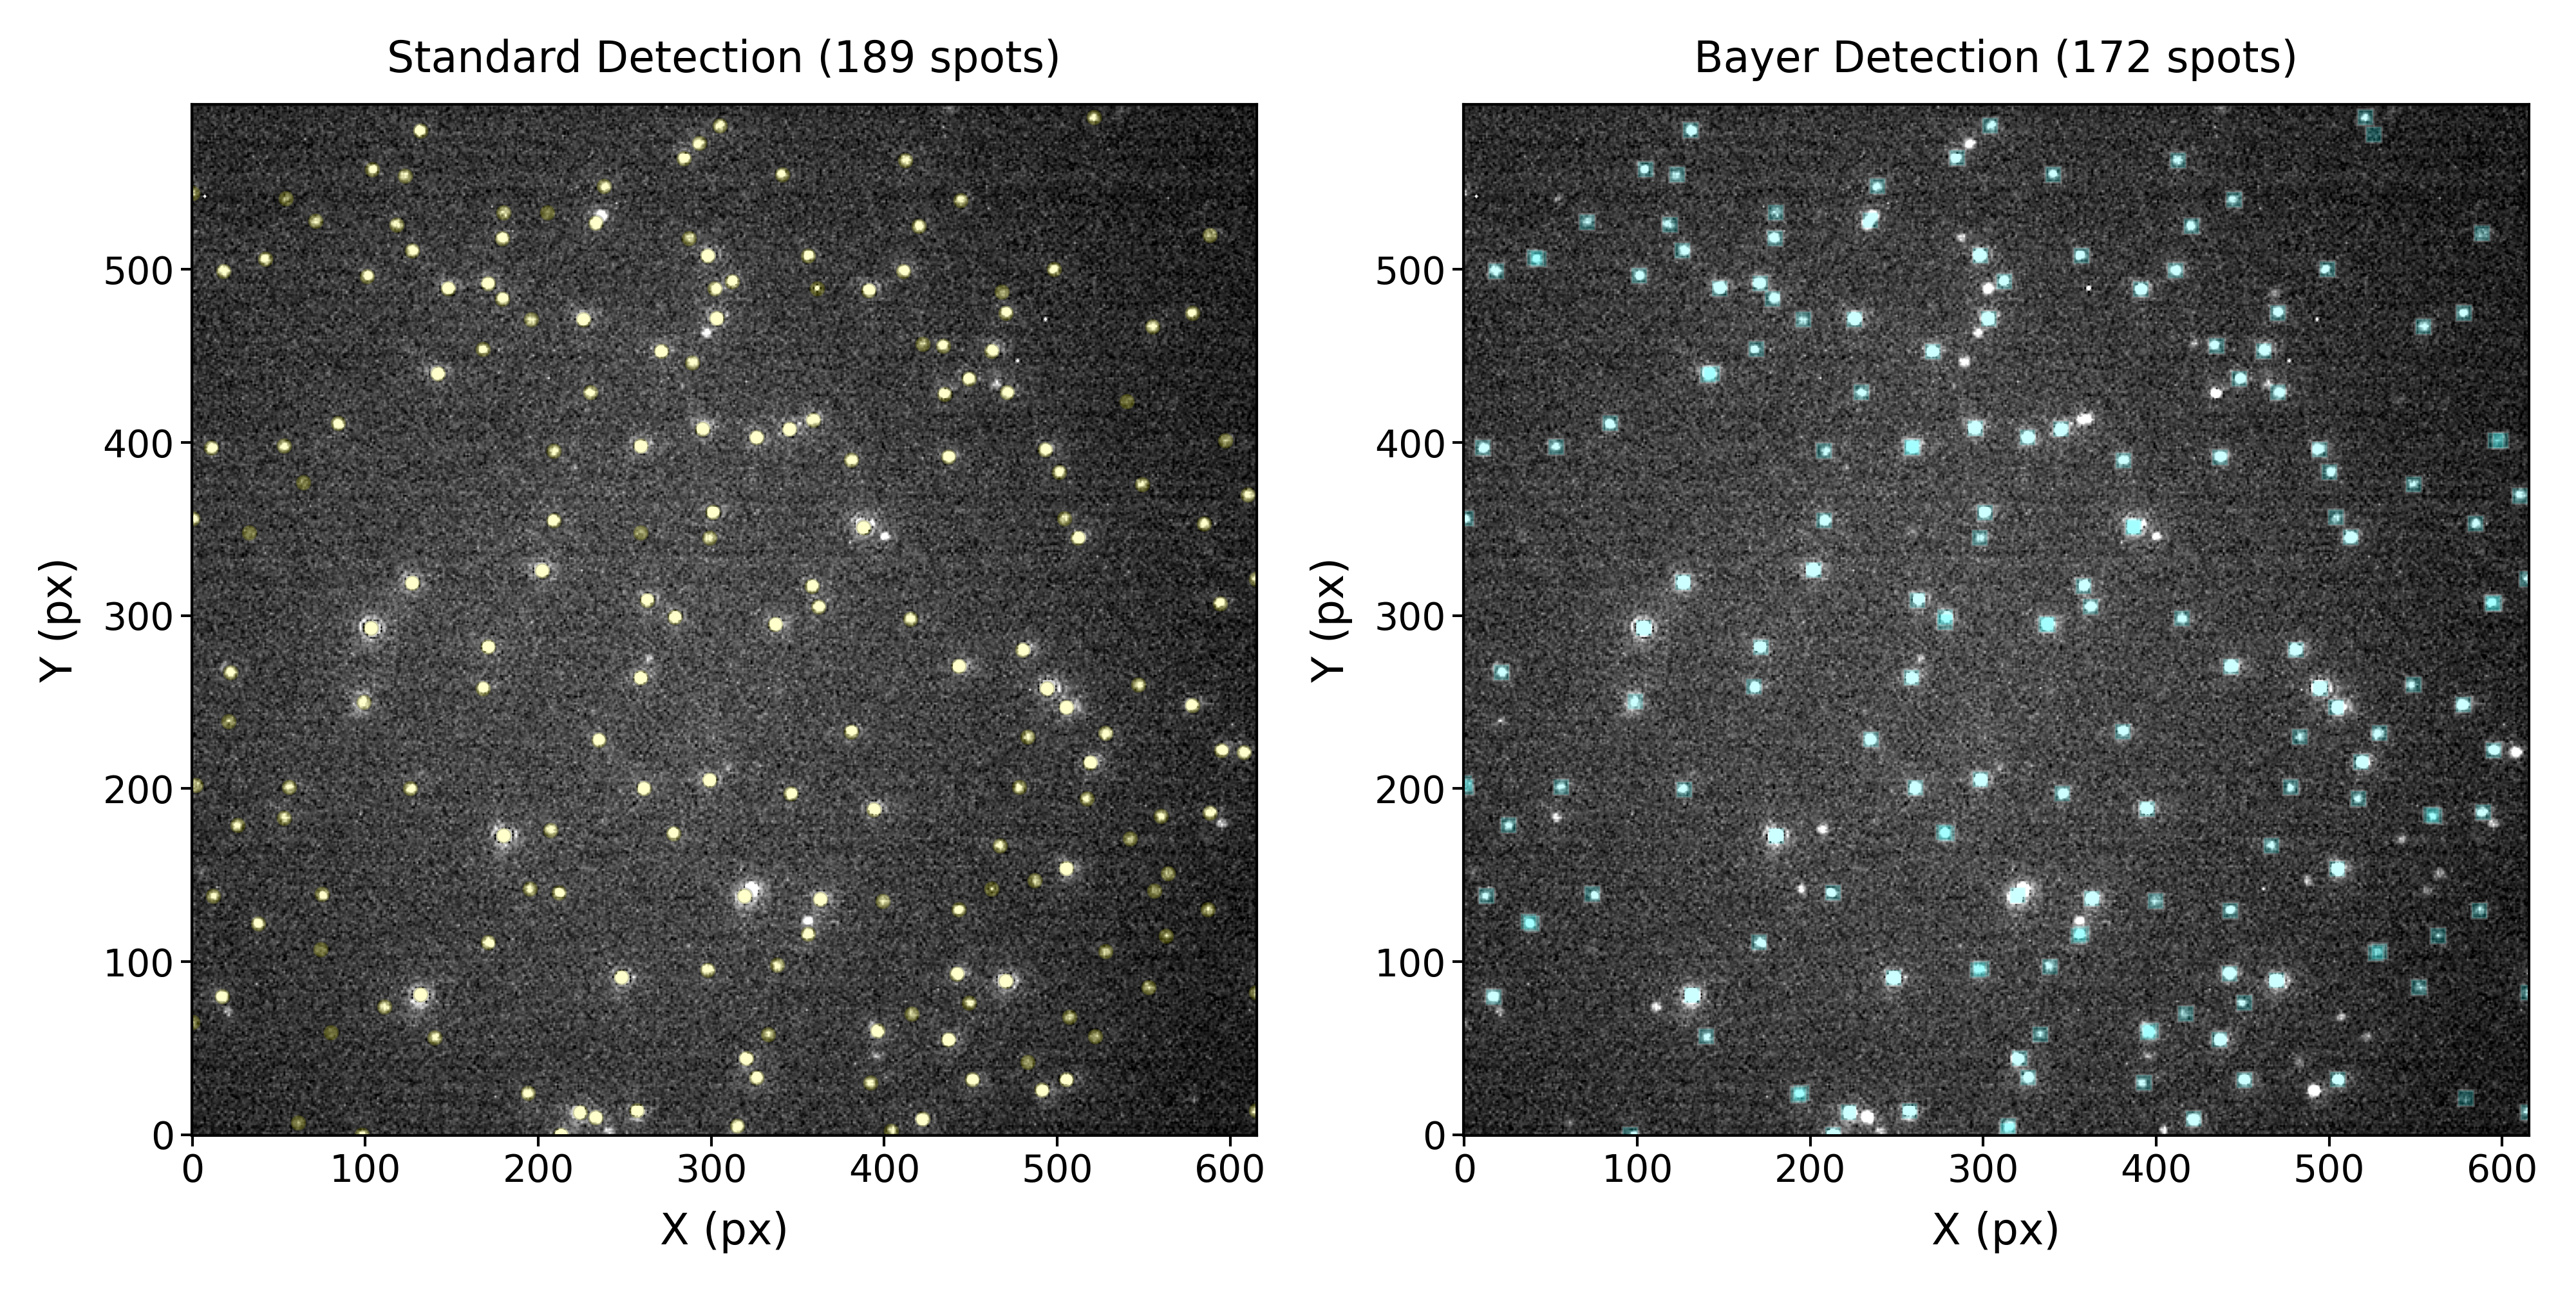

In [7]:
# Create figure
plotter = PublicationPlotter()
fig, axes = plotter.two_column_plot(nrows=1, ncols=2, height=6)

# Calculate percentiles for consistent display
vmin = np.percentile(demosaiced_image, 1)
vmax = np.percentile(demosaiced_image, 99)

# Left: Standard detection
ax = axes[0]
plotter.create_image_plot(ax, demosaiced_image, vmin=vmin, vmax=vmax, cmap='gray')
if detected_puncta_standard is not None and len(detected_puncta_standard) > 0:
    # Format is [row, col] = [y, x], scatter needs (x, y)
    ax.scatter(detected_puncta_standard[:, 1], detected_puncta_standard[:, 0],
              s=marker_size, c='yellow', marker='o', alpha=0.2, 
              linewidths=0.5, edgecolors='black')
plotter.setup_axis(ax, title=f'Standard Detection ({n_standard} spots)',
                  xlabel='X (px)', ylabel='Y (px)', grid=False, equal_aspect=True)

# Right: Bayer detection (merged)
ax = axes[1]
plotter.create_image_plot(ax, demosaiced_image, vmin=vmin, vmax=vmax, cmap='gray')
if detected_puncta_bayer is not None and len(detected_puncta_bayer) > 0:
    # Format is [y, x, frame], scatter needs (x, y)
    # Filter to frame 0 (single frame detection returns frame=0)
    frame_mask = detected_puncta_bayer[:, 2] == 0
    frame_dets = detected_puncta_bayer[frame_mask]
    if len(frame_dets) > 0:
        ax.scatter(frame_dets[:, 1], frame_dets[:, 0],
                  s=marker_size, c='cyan', marker='s', alpha=0.2,
                  linewidths=0.5, edgecolors='white')
plotter.setup_axis(ax, title=f'Bayer Detection ({n_bayer} spots)',
                  xlabel='X (px)', ylabel='Y (px)', grid=False, equal_aspect=True)

plt.tight_layout()
plt.show()

## Visualization: Zoomed Overlay

In [ ]:
# Find highest density region for zoom
if detected_puncta_standard is not None and len(detected_puncta_standard) > 0:
    x_std = detected_puncta_standard[:, 1]  # col = x
    y_std = detected_puncta_standard[:, 0]  # row = y
    
    density_hist, x_edges, y_edges = np.histogram2d(x_std, y_std, bins=50)
    max_density_idx = np.unravel_index(np.argmax(density_hist), density_hist.shape)
    
    center_x = (x_edges[max_density_idx[0]] + x_edges[max_density_idx[0] + 1]) / 2
    center_y = (y_edges[max_density_idx[1]] + y_edges[max_density_idx[1] + 1]) / 2
    
    min_x, max_x = int(center_x - zoom_size), int(center_x + zoom_size)
    min_y, max_y = int(center_y - zoom_size), int(center_y + zoom_size)
else:
    min_x, max_x = width // 2 - zoom_size, width // 2 + zoom_size
    min_y, max_y = height // 2 - zoom_size, height // 2 + zoom_size

print(f"Zoom region: x=[{min_x}, {max_x}], y=[{min_y}, {max_y}]")

# Create zoomed overlay figure
fig, ax = plotter.one_column_plot(height=6)

plotter.create_image_plot(ax, demosaiced_image, vmin=vmin, vmax=vmax, cmap='gray')

# Standard in yellow circles (larger, transparent)
if detected_puncta_standard is not None and len(detected_puncta_standard) > 0:
    ax.scatter(detected_puncta_standard[:, 1], detected_puncta_standard[:, 0],
              s=marker_size*3, c='none', marker='o', alpha=0.7,
              linewidths=2, edgecolors='yellow', label=f'Standard ({n_standard})')

# Bayer in cyan X markers (smaller, opaque)
if detected_puncta_bayer is not None and len(detected_puncta_bayer) > 0:
    frame_mask = detected_puncta_bayer[:, 2] == 0
    frame_dets = detected_puncta_bayer[frame_mask]
    if len(frame_dets) > 0:
        ax.scatter(frame_dets[:, 1], frame_dets[:, 0],
                  s=marker_size*2, c='cyan', marker='x', alpha=0.9,
                  linewidths=2, label=f'Bayer ({n_bayer})')

ax.set_xlim(min_x, max_x)
ax.set_ylim(max_y, min_y)  # Invert y for image coordinates
plotter.setup_axis(ax, title='Overlay: Standard (O) vs Bayer (X)',
                  xlabel='X (px)', ylabel='Y (px)', grid=False, equal_aspect=True)
ax.legend(loc='upper right', framealpha=0.9)
plotter.add_scalebar(ax, pixelsize=69, length_nm=1000, label='1 μm', color='white')

plt.tight_layout()
plt.show()

## Analysis

### Key Observations

1. **Duplicate Removal**: The Bayer approach detects spots in each color channel independently, then merges nearby detections. The metadata shows how many duplicates were removed.

2. **Detection Count Differences**:
   - If Bayer detects **fewer spots**: Could indicate increased false negatives from reduced spatial resolution OR standard method has more false positives from correlated noise
   - If Bayer detects **more spots**: Could indicate better noise handling (preserved independence) OR standard method suppresses true spots due to demosaicing artifacts

3. **Performance**: Bayer approach may be faster or slower depending on the number of channels and merge overhead.

**Ground truth validation needed** to determine which method is more accurate.